# Week 4 - Day 4: Gradient Descent Variants Workshop

**Course:** Deep Neural Network Architectures (21CSE558T)  
**Module:** 2 - Optimization and Regularization  
**Topic:** Comparing Batch, Stochastic, and Mini-batch Gradient Descent

---

## 🎯 Learning Objectives

By the end of this workshop, you will be able to:

1. **Implement** all three gradient descent variants from scratch
2. **Visualize** and compare their convergence patterns
3. **Analyze** computational trade-offs between methods
4. **Select** appropriate GD variant for different scenarios
5. **Tune** hyperparameters effectively

---

## 📚 Background

**Gradient Descent Equation (from Day 3):**
```
θ ← θ - α∇J(θ)
```

**Today's Question:** *How many examples should we use to compute ∇J(θ)?*

- **All examples** → Batch Gradient Descent
- **One example** → Stochastic Gradient Descent  
- **Small batches** → Mini-batch Gradient Descent

## 🔧 Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Tuple, List
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib for better plots
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")
print("🎯 Ready to explore Gradient Descent Variants!")

✅ All libraries imported successfully!
🎯 Ready to explore Gradient Descent Variants!


## 📊 Dataset Creation

Let's create a simple linear regression problem: **y = 2x + 1 + noise**

In [2]:
def create_synthetic_dataset(m: int = 1000, noise_std: float = 0.1) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create synthetic linear regression dataset

    Args:
        m: Number of examples
        noise_std: Standard deviation of noise

    Returns:
        X: Input features (m, 1)
        y: Target values (m,) following y = 2x + 1 + noise
    """
    np.random.seed(42)  # For reproducibility
    X = np.random.randn(m, 1)
    y = 2 * X.squeeze() + 1 + noise_std * np.random.randn(m)

    return X, y

# Create our dataset
X, y = create_synthetic_dataset(m=1000, noise_std=0.1)

print(f"📊 Dataset Created:")
print(f"   Relationship: y = 2x + 1 + noise")
print(f"   Examples: {len(X)}")
print(f"   X range: [{X.min():.2f}, {X.max():.2f}]")
print(f"   y range: [{y.min():.2f}, {y.max():.2f}]")
print(f"   True parameters: w = 2.0, b = 1.0")

📊 Dataset Created:
   Relationship: y = 2x + 1 + noise
   Examples: 1000
   X range: [-3.24, 3.85]
   y range: [-5.43, 8.88]
   True parameters: w = 2.0, b = 1.0


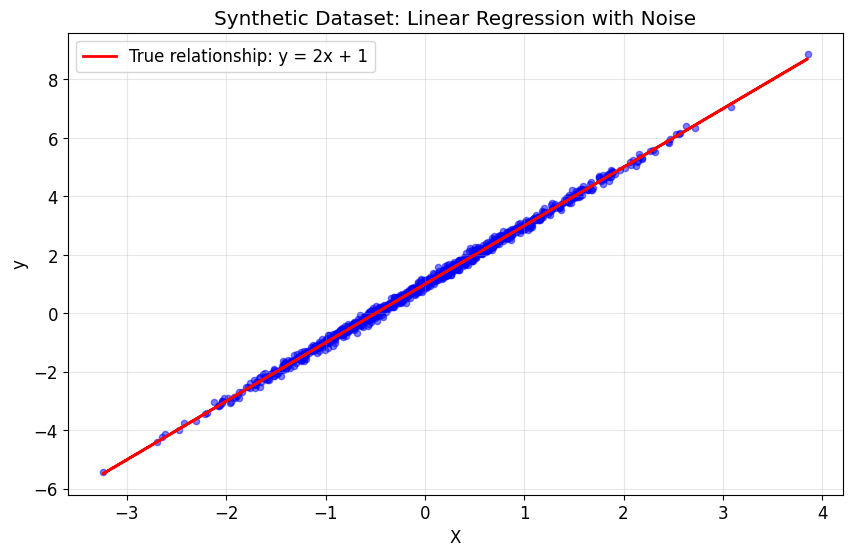

🎯 Our goal: Learn the parameters w=2.0 and b=1.0 from this data!


In [3]:
# Visualize our dataset
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, s=20, color='blue')
plt.plot(X, 2*X + 1, 'r-', linewidth=2, label='True relationship: y = 2x + 1')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Dataset: Linear Regression with Noise')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("🎯 Our goal: Learn the parameters w=2.0 and b=1.0 from this data!")

## 🔍 Helper Functions

Let's create some utility functions we'll use across all implementations.

In [4]:
def compute_cost(predictions: np.ndarray, y_true: np.ndarray) -> float:
    """Compute Mean Squared Error cost"""
    return float(np.mean((predictions - y_true)**2))

def initialize_parameters() -> Tuple[float, float]:
    """Initialize weight and bias with small random values"""
    w = float(np.random.randn() * 0.01)
    b = float(np.random.randn() * 0.01)
    return w, b

def print_progress(epoch: int, cost: float, w: float, b: float, method: str):
    """Print training progress"""
    # Convert to scalar if needed to avoid formatting errors
    cost = float(cost) if hasattr(cost, 'item') else float(cost)
    w = float(w) if hasattr(w, 'item') else float(w)
    b = float(b) if hasattr(b, 'item') else float(b)
    print(f"{method} Epoch {epoch:3d}: Cost = {cost:.8f}, w = {w:.6f}, b = {b:.6f}")

print("✅ Helper functions defined!")

✅ Helper functions defined!


# 🏗️ Implementation 1: Batch Gradient Descent

**The Perfectionist Approach**

- Uses **ALL** training examples to compute each gradient
- **Pros:** Stable, smooth convergence
- **Cons:** Slow for large datasets, memory intensive

**Mathematical Update:**
```
θ^(t+1) = θ^(t) - α · (1/m) Σ(i=1 to m) ∇J(f_θ(x_i), y_i)
```

In [5]:
def batch_gradient_descent(X, y, epochs=100, learning_rate=0.1, verbose=True):
    """
    Batch Gradient Descent Implementation

    Uses the entire dataset to compute gradient at each step.
    Provides smooth, stable convergence but is slow for large datasets.
    """
    start_time = time.time()

    # Initialize parameters
    w, b = initialize_parameters()
    costs = []
    m = len(X)

    if verbose:
        print("\n" + "="*50)
        print("🔵 BATCH GRADIENT DESCENT")
        print("="*50)
        print(f"📊 Dataset size: {m} examples")
        print(f"⚡ Updates per epoch: 1")
        print(f"🎯 Initial: w = {w:.6f}, b = {b:.6f}")
        print(f"📈 Learning rate: {learning_rate}")

    for epoch in range(epochs):
        # Forward pass - compute predictions for ALL examples
        predictions = w * X.squeeze() + b

        # Compute cost using entire dataset
        cost = compute_cost(predictions, y)
        costs.append(cost)

        # Compute gradients using ALL examples
        # dJ/dw = (1/m) * Σ(predictions - y) * X
        # dJ/db = (1/m) * Σ(predictions - y)
        dw = np.mean((predictions - y) * X.squeeze())
        db = np.mean(predictions - y)

        # Parameter update - SINGLE update per epoch
        w -= learning_rate * dw
        b -= learning_rate * db

        # Progress logging
        if verbose and (epoch % 20 == 0 or epoch < 10):
            print_progress(epoch, cost, w, b, "BGD")

    time_taken = time.time() - start_time

    if verbose:
        print(f"\n🎯 Final Results:")
        print(f"   w = {w:.6f}, b = {b:.6f}")
        print(f"   Final cost = {costs[-1]:.8f}")
        print(f"   Time taken = {time_taken:.3f} seconds")
        print(f"   Total parameter updates: {epochs}")

    return w, b, costs, time_taken

In [6]:
# Run Batch Gradient Descent
print("🚀 Running Batch Gradient Descent...")
w_batch, b_batch, costs_batch, time_batch = batch_gradient_descent(X, y, epochs=100, learning_rate=0.1)

🚀 Running Batch Gradient Descent...

🔵 BATCH GRADIENT DESCENT
📊 Dataset size: 1000 examples
⚡ Updates per epoch: 1
🎯 Initial: w = -0.006752, b = -0.001445
📈 Learning rate: 0.1
BGD Epoch   0: Cost = 4.94853826, w = 0.187106, b = 0.103287
BGD Epoch   1: Cost = 4.02530755, w = 0.362185, b = 0.197172
BGD Epoch   2: Cost = 3.27479426, w = 0.520305, b = 0.281329
BGD Epoch   3: Cost = 2.66466287, w = 0.663110, b = 0.356765
BGD Epoch   4: Cost = 2.16863599, w = 0.792084, b = 0.424381
BGD Epoch   5: Cost = 1.76535854, w = 0.908569, b = 0.484987
BGD Epoch   6: Cost = 1.43747499, w = 1.013773, b = 0.539306
BGD Epoch   7: Cost = 1.17087985, w = 1.108791, b = 0.587991
BGD Epoch   8: Cost = 0.95410851, w = 1.194610, b = 0.631623
BGD Epoch   9: Cost = 0.77784254, w = 1.272120, b = 0.670726
BGD Epoch  20: Cost = 0.08922662, w = 1.759400, b = 0.907051
BGD Epoch  40: Cost = 0.01121679, w = 1.964867, b = 0.996272
BGD Epoch  60: Cost = 0.00994442, w = 1.991804, b = 1.006007
BGD Epoch  80: Cost = 0.0099233

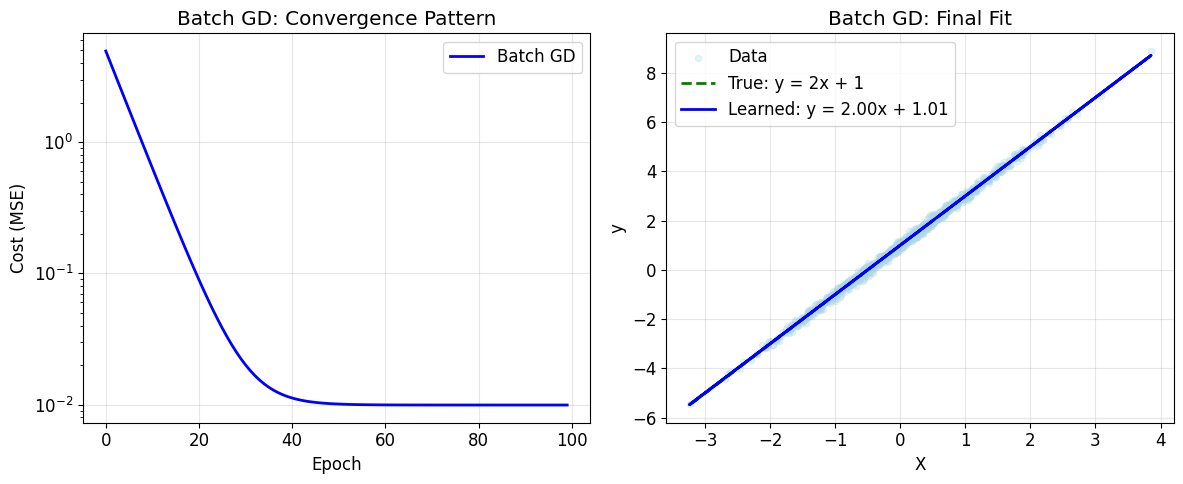

📊 Batch GD Results:
   True parameters:    w = 2.000, b = 1.000
   Learned parameters: w = 1.996, b = 1.007
   Error: w_error = 0.004194, b_error = 0.007150


In [7]:
# Visualize Batch GD convergence
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(costs_batch, 'b-', linewidth=2, label='Batch GD')
plt.title('Batch GD: Convergence Pattern')
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.3, s=20, color='lightblue', label='Data')
plt.plot(X, 2*X + 1, 'g--', linewidth=2, label='True: y = 2x + 1')
plt.plot(X, w_batch*X + b_batch, 'b-', linewidth=2,
         label=f'Learned: y = {w_batch:.2f}x + {b_batch:.2f}')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Batch GD: Final Fit')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Batch GD Results:")
print(f"   True parameters:    w = 2.000, b = 1.000")
print(f"   Learned parameters: w = {w_batch:.3f}, b = {b_batch:.3f}")
print(f"   Error: w_error = {abs(w_batch-2):.6f}, b_error = {abs(b_batch-1):.6f}")

# ⚡ Implementation 2: Stochastic Gradient Descent

**The Speed Demon Approach**

- Updates parameters after **each individual** training example
- **Pros:** Fast updates, memory efficient, can escape local minima
- **Cons:** Noisy convergence, unstable, requires careful tuning

**Mathematical Update:**
```
θ^(t+1) = θ^(t) - α · ∇J(f_θ(x_i), y_i)  [for randomly selected i]
```

In [8]:
def stochastic_gradient_descent(X, y, epochs=100, learning_rate=0.01, verbose=True):
    """
    Stochastic Gradient Descent Implementation

    Updates parameters after each individual training example.
    Fast updates but noisy convergence pattern.
    """
    start_time = time.time()

    # Initialize parameters
    w, b = initialize_parameters()
    costs = []
    m = len(X)

    if verbose:
        print("\n" + "="*50)
        print("🔴 STOCHASTIC GRADIENT DESCENT")
        print("="*50)
        print(f"📊 Dataset size: {m} examples")
        print(f"⚡ Updates per epoch: {m}")
        print(f"🎯 Initial: w = {w:.6f}, b = {b:.6f}")
        print(f"📈 Learning rate: {learning_rate} (smaller than BGD)")

    for epoch in range(epochs):
        epoch_cost = 0

        # Shuffle data each epoch for better convergence
        indices = np.random.permutation(m)

        # Process each example individually
        for idx in indices:
            # Forward pass - SINGLE example
            x_i = float(X[idx].squeeze())  # Ensure scalar
            y_i = float(y[idx])            # Ensure scalar
            prediction = w * x_i + b

            # Accumulate cost for epoch average
            cost_i = (prediction - y_i)**2
            epoch_cost += cost_i

            # Compute gradients for SINGLE example
            # dJ/dw = (prediction - y_i) * x_i
            # dJ/db = (prediction - y_i)
            dw = (prediction - y_i) * x_i
            db = (prediction - y_i)

            # Immediate parameter update
            w -= learning_rate * dw
            b -= learning_rate * db

        # Average cost for the epoch
        avg_cost = epoch_cost / m
        costs.append(float(avg_cost))

        # Progress logging
        if verbose and (epoch % 20 == 0 or epoch < 10):
            print_progress(epoch, avg_cost, w, b, "SGD")

    time_taken = time.time() - start_time

    if verbose:
        print(f"\n🎯 Final Results:")
        print(f"   w = {w:.6f}, b = {b:.6f}")
        print(f"   Final cost = {costs[-1]:.8f}")
        print(f"   Time taken = {time_taken:.3f} seconds")
        print(f"   Total parameter updates: {epochs * m}")

    return w, b, costs, time_taken

In [9]:
# Run Stochastic Gradient Descent
print("🚀 Running Stochastic Gradient Descent...")
w_sgd, b_sgd, costs_sgd, time_sgd = stochastic_gradient_descent(X, y, epochs=100, learning_rate=0.01)

🚀 Running Stochastic Gradient Descent...

🔴 STOCHASTIC GRADIENT DESCENT
📊 Dataset size: 1000 examples
⚡ Updates per epoch: 1000
🎯 Initial: w = -0.007924, b = -0.003080
📈 Learning rate: 0.01 (smaller than BGD)
SGD Epoch   0: Cost = 0.26449501, w = 2.002131, b = 1.007075
SGD Epoch   1: Cost = 0.01006084, w = 1.989832, b = 1.005331
SGD Epoch   2: Cost = 0.01006857, w = 1.994200, b = 1.001247
SGD Epoch   3: Cost = 0.01006956, w = 1.994941, b = 1.004917
SGD Epoch   4: Cost = 0.01008188, w = 1.995113, b = 1.005935
SGD Epoch   5: Cost = 0.01002102, w = 1.988543, b = 1.011251
SGD Epoch   6: Cost = 0.01001017, w = 2.002335, b = 0.996848
SGD Epoch   7: Cost = 0.01001468, w = 2.007844, b = 1.013541
SGD Epoch   8: Cost = 0.01005755, w = 1.987738, b = 1.014863
SGD Epoch   9: Cost = 0.01002913, w = 1.990601, b = 1.005906
SGD Epoch  20: Cost = 0.01003959, w = 1.994284, b = 1.010379
SGD Epoch  40: Cost = 0.01002698, w = 1.984961, b = 1.007438
SGD Epoch  60: Cost = 0.00999874, w = 1.995029, b = 1.00972

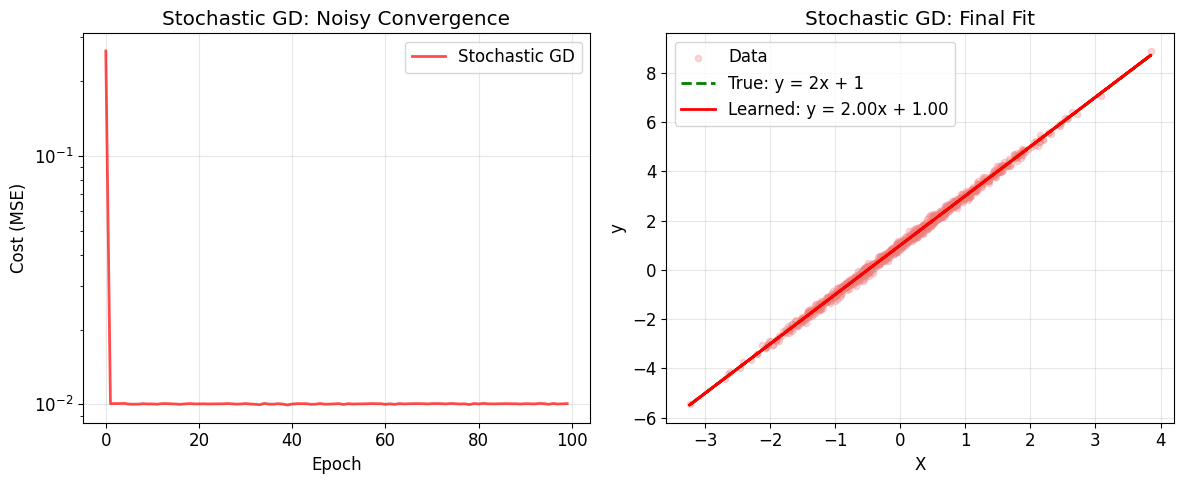

📊 Stochastic GD Results:
   True parameters:    w = 2.000, b = 1.000
   Learned parameters: w = 2.003, b = 1.005
   Error: w_error = 0.002651, b_error = 0.004852


In [10]:
# Visualize SGD convergence
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(costs_sgd, 'r-', alpha=0.7, linewidth=2, label='Stochastic GD')
plt.title('Stochastic GD: Noisy Convergence')
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.3, s=20, color='lightcoral', label='Data')
plt.plot(X, 2*X + 1, 'g--', linewidth=2, label='True: y = 2x + 1')
plt.plot(X, w_sgd*X + b_sgd, 'r-', linewidth=2,
         label=f'Learned: y = {w_sgd:.2f}x + {b_sgd:.2f}')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Stochastic GD: Final Fit')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Stochastic GD Results:")
print(f"   True parameters:    w = 2.000, b = 1.000")
print(f"   Learned parameters: w = {w_sgd:.3f}, b = {b_sgd:.3f}")
print(f"   Error: w_error = {abs(w_sgd-2):.6f}, b_error = {abs(b_sgd-1):.6f}")

# ⚖️ Implementation 3: Mini-batch Gradient Descent

**The Goldilocks Solution**

- Uses **small batches** of examples (typically 16-256)
- **Pros:** Balanced convergence, GPU-friendly, practical
- **Cons:** Need to choose batch size

**Mathematical Update:**
```
θ^(t+1) = θ^(t) - α · (1/|B|) Σ(i∈B) ∇J(f_θ(x_i), y_i)  [B = mini-batch]
```

In [11]:
def mini_batch_gradient_descent(X, y, batch_size=32, epochs=100, learning_rate=0.05, verbose=True):
    """
    Mini-batch Gradient Descent Implementation

    Updates parameters using small batches of examples.
    Balances the stability of BGD with the speed of SGD.
    """
    start_time = time.time()

    # Initialize parameters
    w, b = initialize_parameters()
    costs = []
    m = len(X)

    # Calculate number of batches per epoch
    num_batches = int(np.ceil(m / batch_size))

    if verbose:
        print("\n" + "="*50)
        print("🟢 MINI-BATCH GRADIENT DESCENT")
        print("="*50)
        print(f"📊 Dataset size: {m} examples")
        print(f"📦 Batch size: {batch_size}")
        print(f"⚡ Updates per epoch: {num_batches}")
        print(f"🎯 Initial: w = {w:.6f}, b = {b:.6f}")
        print(f"📈 Learning rate: {learning_rate}")

    for epoch in range(epochs):
        epoch_cost = 0

        # Shuffle data each epoch
        indices = np.random.permutation(m)

        # Process data in mini-batches
        for i in range(0, m, batch_size):
            # Create mini-batch
            end_idx = min(i + batch_size, m)
            batch_indices = indices[i:end_idx]

            X_batch = X[batch_indices]
            y_batch = y[batch_indices]
            batch_m = len(X_batch)

            # Forward pass - BATCH of examples
            predictions = w * X_batch.squeeze() + b

            # Compute cost for this batch
            batch_cost = compute_cost(predictions, y_batch)
            epoch_cost += batch_cost * batch_m

            # Compute gradients for BATCH
            # dJ/dw = (1/batch_m) * Σ(predictions - y_batch) * X_batch
            # dJ/db = (1/batch_m) * Σ(predictions - y_batch)
            dw = np.mean((predictions - y_batch) * X_batch.squeeze())
            db = np.mean(predictions - y_batch)

            # Parameter update after each batch
            w -= learning_rate * dw
            b -= learning_rate * db

        # Average cost for the epoch
        avg_cost = epoch_cost / m
        costs.append(avg_cost)

        # Progress logging
        if verbose and (epoch % 20 == 0 or epoch < 10):
            print_progress(epoch, avg_cost, w, b, "MBG")

    time_taken = time.time() - start_time

    if verbose:
        print(f"\n🎯 Final Results:")
        print(f"   w = {w:.6f}, b = {b:.6f}")
        print(f"   Final cost = {costs[-1]:.8f}")
        print(f"   Time taken = {time_taken:.3f} seconds")
        print(f"   Total parameter updates: {epochs * num_batches}")

    return w, b, costs, time_taken

In [12]:
# Run Mini-batch Gradient Descent
print("🚀 Running Mini-batch Gradient Descent...")
w_mb, b_mb, costs_mb, time_mb = mini_batch_gradient_descent(X, y, batch_size=32, epochs=100, learning_rate=0.05)

🚀 Running Mini-batch Gradient Descent...

🟢 MINI-BATCH GRADIENT DESCENT
📊 Dataset size: 1000 examples
📦 Batch size: 32
⚡ Updates per epoch: 32
🎯 Initial: w = -0.010071, b = -0.008852
📈 Learning rate: 0.05
MBG Epoch   0: Cost = 1.60222169, w = 1.574511, b = 0.819347
MBG Epoch   1: Cost = 0.07701796, w = 1.909915, b = 0.969353
MBG Epoch   2: Cost = 0.01268016, w = 1.978986, b = 1.002689
MBG Epoch   3: Cost = 0.01005314, w = 1.990979, b = 1.005794
MBG Epoch   4: Cost = 0.00995395, w = 1.995424, b = 1.007919
MBG Epoch   5: Cost = 0.00994759, w = 2.000039, b = 1.006290
MBG Epoch   6: Cost = 0.00994888, w = 1.996998, b = 1.006628
MBG Epoch   7: Cost = 0.00994177, w = 2.000869, b = 1.006797
MBG Epoch   8: Cost = 0.00995531, w = 1.997205, b = 1.009960
MBG Epoch   9: Cost = 0.00994741, w = 1.995389, b = 1.008899
MBG Epoch  20: Cost = 0.00995803, w = 1.994540, b = 1.009509
MBG Epoch  40: Cost = 0.00994642, w = 1.995246, b = 1.006324
MBG Epoch  60: Cost = 0.00994689, w = 1.994916, b = 1.009007
MB

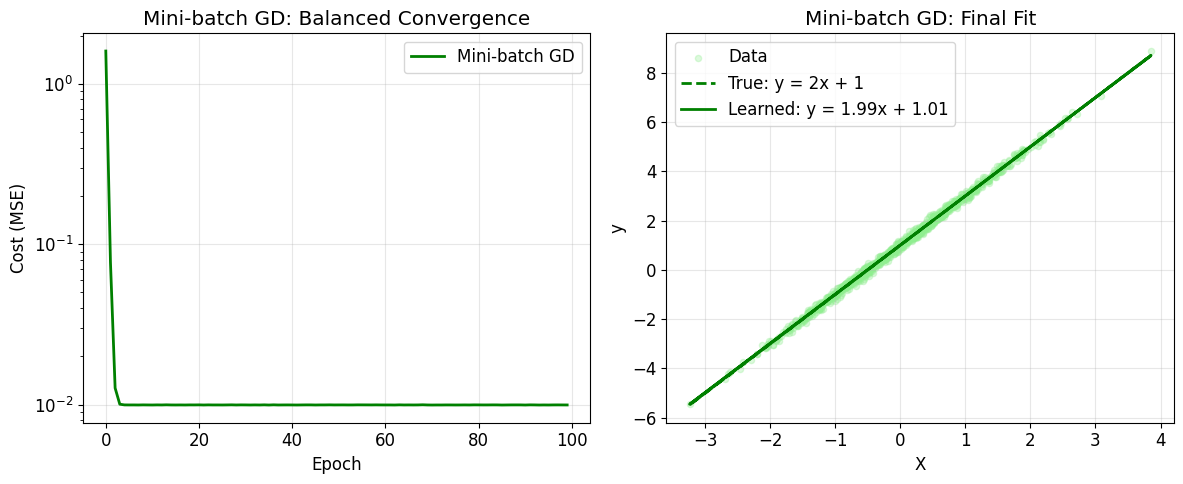

📊 Mini-batch GD Results:
   True parameters:    w = 2.000, b = 1.000
   Learned parameters: w = 1.994, b = 1.010
   Error: w_error = 0.006276, b_error = 0.010164


In [13]:
# Visualize Mini-batch GD convergence
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(costs_mb, 'g-', linewidth=2, label='Mini-batch GD')
plt.title('Mini-batch GD: Balanced Convergence')
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.3, s=20, color='lightgreen', label='Data')
plt.plot(X, 2*X + 1, 'g--', linewidth=2, label='True: y = 2x + 1')
plt.plot(X, w_mb*X + b_mb, 'g-', linewidth=2,
         label=f'Learned: y = {w_mb:.2f}x + {b_mb:.2f}')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Mini-batch GD: Final Fit')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Mini-batch GD Results:")
print(f"   True parameters:    w = 2.000, b = 1.000")
print(f"   Learned parameters: w = {w_mb:.3f}, b = {b_mb:.3f}")
print(f"   Error: w_error = {abs(w_mb-2):.6f}, b_error = {abs(b_mb-1):.6f}")

# 📊 Comprehensive Comparison

Now let's compare all three methods side by side!

In [14]:
# Create comprehensive comparison
def compare_all_methods():
    """Compare all three gradient descent variants"""

    print("\n" + "="*80)
    print("🏆 COMPREHENSIVE COMPARISON RESULTS")
    print("="*80)

    # Results table
    methods = ["Batch GD", "Stochastic GD", "Mini-batch GD"]
    weights = [w_batch, w_sgd, w_mb]
    biases = [b_batch, b_sgd, b_mb]
    final_costs = [costs_batch[-1], costs_sgd[-1], costs_mb[-1]]
    times = [time_batch, time_sgd, time_mb]

    print(f"{'Method':<15} {'Weight':<10} {'Bias':<10} {'Final Cost':<12} {'Time (s)':<10}")
    print("-" * 65)
    for i in range(3):
        print(f"{methods[i]:<15} {weights[i]:<10.4f} {biases[i]:<10.4f} "
              f"{final_costs[i]:<12.8f} {times[i]:<10.3f}")

    print(f"\n🎯 True parameters: w = 2.0000, b = 1.0000")

    # Error analysis
    print(f"\n📊 Error Analysis (|predicted - true|):")
    w_errors = [abs(w - 2.0) for w in weights]
    b_errors = [abs(b - 1.0) for b in biases]

    for i in range(3):
        print(f"   {methods[i]:<15} Weight Error: {w_errors[i]:.6f}, "
              f"Bias Error: {b_errors[i]:.6f}")

compare_all_methods()


🏆 COMPREHENSIVE COMPARISON RESULTS
Method          Weight     Bias       Final Cost   Time (s)  
-----------------------------------------------------------------
Batch GD        1.9958     1.0072     0.00992299   0.006     
Stochastic GD   2.0027     1.0049     0.01006087   0.090     
Mini-batch GD   1.9937     1.0102     0.00994548   0.199     

🎯 True parameters: w = 2.0000, b = 1.0000

📊 Error Analysis (|predicted - true|):
   Batch GD        Weight Error: 0.004194, Bias Error: 0.007150
   Stochastic GD   Weight Error: 0.002651, Bias Error: 0.004852
   Mini-batch GD   Weight Error: 0.006276, Bias Error: 0.010164


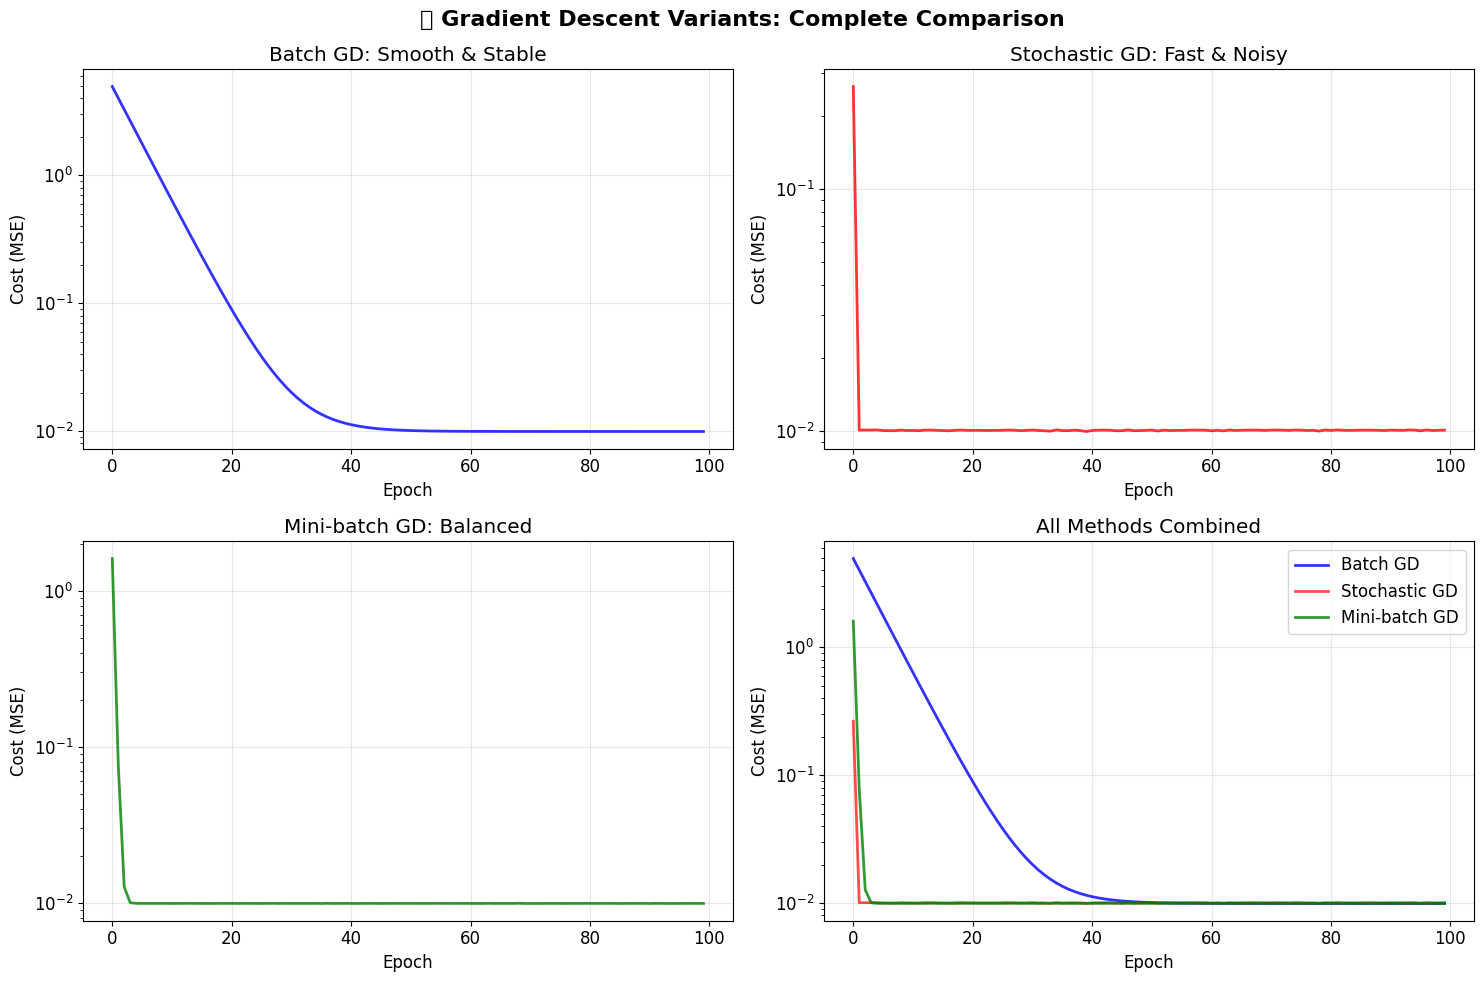


📈 Key Observations:
   🔵 Batch GD: Smoothest convergence, most stable
   🔴 Stochastic GD: Noisiest but explores more
   🟢 Mini-batch GD: Best balance for practical use


In [15]:
# Create detailed comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('🏆 Gradient Descent Variants: Complete Comparison', fontsize=16, fontweight='bold')

# Individual convergence plots
costs_data = [costs_batch, costs_sgd, costs_mb]
colors = ['blue', 'red', 'green']
methods = ['Batch GD: Smooth & Stable', 'Stochastic GD: Fast & Noisy', 'Mini-batch GD: Balanced']

for i, (costs, method, color) in enumerate(zip(costs_data, methods, colors)):
    row, col = i // 2, i % 2
    if i < 3:
        axes[row, col].plot(costs, color=color, linewidth=2, alpha=0.8)
        axes[row, col].set_title(method)
        axes[row, col].set_xlabel('Epoch')
        axes[row, col].set_ylabel('Cost (MSE)')
        axes[row, col].grid(True, alpha=0.3)
        axes[row, col].set_yscale('log')

# Combined comparison plot
axes[1, 1].plot(costs_batch, 'b-', linewidth=2, label='Batch GD', alpha=0.8)
axes[1, 1].plot(costs_sgd, 'r-', linewidth=2, label='Stochastic GD', alpha=0.7)
axes[1, 1].plot(costs_mb, 'g-', linewidth=2, label='Mini-batch GD', alpha=0.8)
axes[1, 1].set_title('All Methods Combined')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Cost (MSE)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

print("\n📈 Key Observations:")
print("   🔵 Batch GD: Smoothest convergence, most stable")
print("   🔴 Stochastic GD: Noisiest but explores more")
print("   🟢 Mini-batch GD: Best balance for practical use")

# 🧪 Experimentation Section

Let's experiment with different settings to understand the trade-offs better!

## 🔬 Experiment 1: Batch Size Impact

In [16]:
def experiment_batch_sizes(batch_sizes=[1, 8, 16, 32, 64, 128], epochs=50):
    """Experiment with different batch sizes for mini-batch GD"""

    print(f"\n🔬 EXPERIMENT 1: Batch Size Impact")
    print(f"📊 Testing batch sizes: {batch_sizes}")

    results = {}

    for batch_size in batch_sizes:
        print(f"\n🧪 Testing batch_size = {batch_size}")

        if batch_size >= len(X):
            # If batch size >= dataset size, this becomes batch GD
            w, b, costs, time_taken = batch_gradient_descent(
                X, y, epochs=epochs, verbose=False
            )
            method_name = "Batch GD"
        else:
            w, b, costs, time_taken = mini_batch_gradient_descent(
                X, y, batch_size=batch_size, epochs=epochs, verbose=False
            )
            method_name = f"Mini-batch (size={batch_size})"

        results[batch_size] = {
            'w': w, 'b': b, 'final_cost': costs[-1],
            'time': time_taken, 'costs': costs,
            'method': method_name
        }

        print(f"   {method_name}: w={w:.4f}, b={b:.4f}, "
              f"final_cost={costs[-1]:.6f}, time={time_taken:.3f}s")

    return results

# Run the experiment
batch_results = experiment_batch_sizes()


🔬 EXPERIMENT 1: Batch Size Impact
📊 Testing batch sizes: [1, 8, 16, 32, 64, 128]

🧪 Testing batch_size = 1
   Mini-batch (size=1): w=2.0474, b=1.0055, final_cost=0.010422, time=1.567s

🧪 Testing batch_size = 8
   Mini-batch (size=8): w=1.9953, b=1.0095, final_cost=0.010018, time=0.169s

🧪 Testing batch_size = 16
   Mini-batch (size=16): w=1.9923, b=1.0057, final_cost=0.009978, time=0.138s

🧪 Testing batch_size = 32
   Mini-batch (size=32): w=1.9965, b=1.0054, final_cost=0.009944, time=0.044s

🧪 Testing batch_size = 64
   Mini-batch (size=64): w=1.9964, b=1.0065, final_cost=0.009935, time=0.023s

🧪 Testing batch_size = 128
   Mini-batch (size=128): w=1.9962, b=1.0074, final_cost=0.009928, time=0.012s


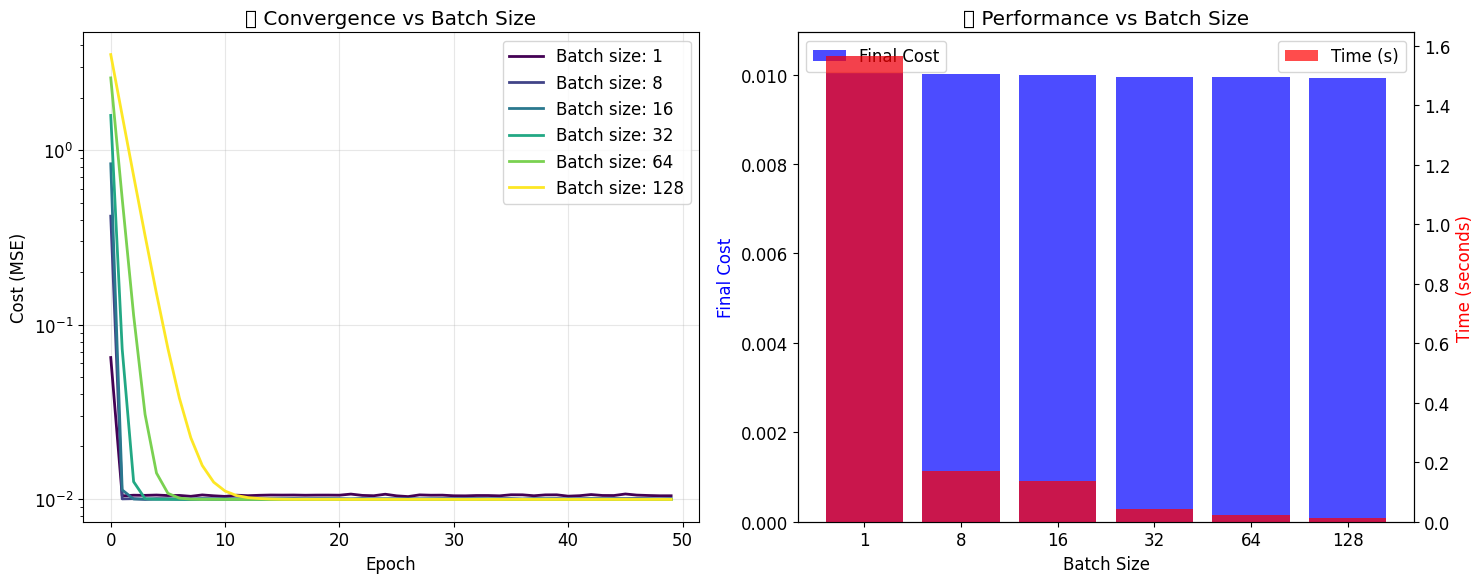


📊 Batch Size Analysis:
   Batch size   1: Final cost = 0.010422, Time = 1.567s
   Batch size   8: Final cost = 0.010018, Time = 0.169s
   Batch size  16: Final cost = 0.009978, Time = 0.138s
   Batch size  32: Final cost = 0.009944, Time = 0.044s
   Batch size  64: Final cost = 0.009935, Time = 0.023s
   Batch size 128: Final cost = 0.009928, Time = 0.012s


In [17]:
# Visualize batch size experiment results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot convergence curves
batch_sizes = list(batch_results.keys())
colors = plt.cm.viridis(np.linspace(0, 1, len(batch_sizes)))

for batch_size, color in zip(batch_sizes, colors):
    costs = batch_results[batch_size]['costs']
    ax1.plot(costs, label=f'Batch size: {batch_size}', linewidth=2, color=color)

ax1.set_title('🔬 Convergence vs Batch Size')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cost (MSE)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Plot performance metrics
final_costs = [batch_results[bs]['final_cost'] for bs in batch_sizes]
times = [batch_results[bs]['time'] for bs in batch_sizes]

ax2_twin = ax2.twinx()

bars1 = ax2.bar([f'{bs}' for bs in batch_sizes], final_costs,
               alpha=0.7, color='blue', label='Final Cost')
bars2 = ax2_twin.bar([f'{bs}' for bs in batch_sizes], times,
                   alpha=0.7, color='red', label='Time (s)')

ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Final Cost', color='blue')
ax2_twin.set_ylabel('Time (seconds)', color='red')
ax2.set_title('🏆 Performance vs Batch Size')

ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\n📊 Batch Size Analysis:")
for bs in batch_sizes:
    print(f"   Batch size {bs:3d}: Final cost = {batch_results[bs]['final_cost']:.6f}, "
          f"Time = {batch_results[bs]['time']:.3f}s")

## 🔬 Experiment 2: Learning Rate Sensitivity

In [18]:
def experiment_learning_rates(learning_rates=[0.001, 0.01, 0.05, 0.1, 0.5, 1.0], epochs=50):
    """Test different learning rates with mini-batch GD"""

    print(f"\n🔬 EXPERIMENT 2: Learning Rate Sensitivity")
    print(f"📈 Testing learning rates: {learning_rates}")

    results = {}

    for lr in learning_rates:
        print(f"\n🧪 Testing learning_rate = {lr}")

        try:
            w, b, costs, time_taken = mini_batch_gradient_descent(
                X, y, batch_size=32, epochs=epochs, learning_rate=lr, verbose=False
            )

            results[lr] = {
                'w': w, 'b': b, 'final_cost': costs[-1],
                'time': time_taken, 'costs': costs,
                'converged': costs[-1] < 10
            }

            status = "✅ Converged" if costs[-1] < 10 else "⚠️ High cost"
            print(f"   Result: w={w:.4f}, b={b:.4f}, final_cost={costs[-1]:.6f} {status}")

        except Exception as e:
            results[lr] = {'error': str(e), 'converged': False}
            print(f"   ❌ ERROR: Learning rate too large - likely diverged!")

    return results

# Run the experiment
lr_results = experiment_learning_rates()


🔬 EXPERIMENT 2: Learning Rate Sensitivity
📈 Testing learning rates: [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

🧪 Testing learning_rate = 0.001
   Result: w=1.5704, b=0.8161, final_cost=0.230077 ✅ Converged

🧪 Testing learning_rate = 0.01
   Result: w=1.9959, b=1.0074, final_cost=0.009929 ✅ Converged

🧪 Testing learning_rate = 0.05
   Result: w=1.9996, b=1.0066, final_cost=0.009949 ✅ Converged

🧪 Testing learning_rate = 0.1
   Result: w=1.9985, b=1.0052, final_cost=0.009969 ✅ Converged

🧪 Testing learning_rate = 0.5
   Result: w=2.0065, b=0.9843, final_cost=0.010161 ✅ Converged

🧪 Testing learning_rate = 1.0
   Result: w=1.9952, b=1.0031, final_cost=0.010732 ✅ Converged


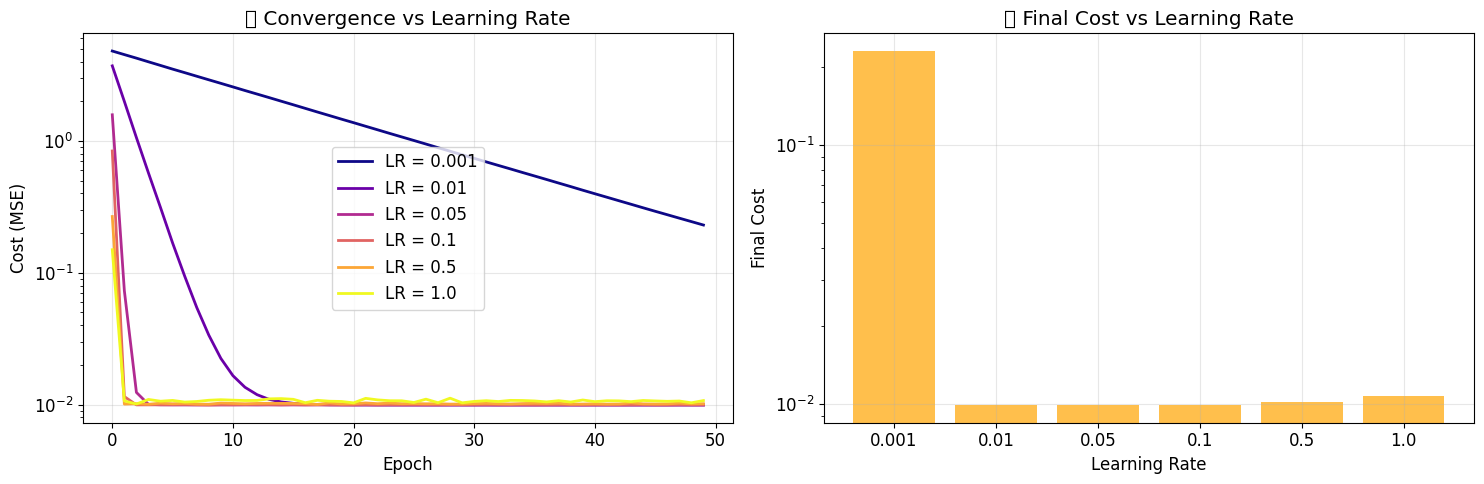


📊 Learning Rate Analysis:
   LR 0.001: Final cost = 0.230077 (Too high)
   LR 0.010: Final cost = 0.009929 (Good)
   LR 0.050: Final cost = 0.009949 (Good)
   LR 0.100: Final cost = 0.009969 (Good)
   LR 0.500: Final cost = 0.010161 (Good)
   LR 1.000: Final cost = 0.010732 (Good)


In [19]:
# Visualize learning rate experiment
plt.figure(figsize=(15, 5))

# Filter out failed experiments
successful_lrs = [lr for lr, result in lr_results.items() if 'costs' in result]
colors = plt.cm.plasma(np.linspace(0, 1, len(successful_lrs)))

plt.subplot(1, 2, 1)
for lr, color in zip(successful_lrs, colors):
    costs = lr_results[lr]['costs']
    plt.plot(costs, label=f'LR = {lr}', linewidth=2, color=color)

plt.title('🔬 Convergence vs Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Performance analysis
plt.subplot(1, 2, 2)
final_costs = [lr_results[lr]['final_cost'] for lr in successful_lrs]
plt.bar([str(lr) for lr in successful_lrs], final_costs,
        alpha=0.7, color='orange')
plt.title('🏆 Final Cost vs Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Final Cost')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Learning Rate Analysis:")
for lr in sorted(lr_results.keys()):
    result = lr_results[lr]
    if 'costs' in result:
        status = "Good" if result['final_cost'] < 0.1 else "Too high"
        print(f"   LR {lr:4.3f}: Final cost = {result['final_cost']:.6f} ({status})")
    else:
        print(f"   LR {lr:4.3f}: ❌ Diverged")

# 📚 Student Exercises

Now it's your turn to experiment!

## 💡 Exercise 1: Prediction Challenge

Before running the code below, predict the outcomes!

In [20]:
# Exercise 1: Make predictions before running!
print("🤔 PREDICTION CHALLENGE")
print("Before running the experiments below, predict:")
print("")
print("1. Which will converge fastest: batch_size=16 or batch_size=128?")
print("2. Which will be more stable: learning_rate=0.01 or 0.1?")
print("3. Which will use more memory: Batch GD or Mini-batch GD?")
print("4. Which will make more parameter updates per epoch: SGD or Mini-batch?")
print("")
print("Write your predictions, then run the experiments to check!")

# TODO: Students write their predictions here as comments
# My predictions:
# 1.
# 2.
# 3.
# 4.

🤔 PREDICTION CHALLENGE
Before running the experiments below, predict:

1. Which will converge fastest: batch_size=16 or batch_size=128?
2. Which will be more stable: learning_rate=0.01 or 0.1?
3. Which will use more memory: Batch GD or Mini-batch GD?
4. Which will make more parameter updates per epoch: SGD or Mini-batch?

Write your predictions, then run the experiments to check!


## 💡 Exercise 2: Custom Implementation

Implement your own variant with modifications!

In [21]:
# Exercise 2: Custom Implementation
def your_custom_gradient_descent(X, y, epochs=100, **kwargs):
    """
    TODO: Implement your own gradient descent variant!

    Ideas to try:
    - Adaptive learning rate (decrease over time)
    - Different batch size scheduling
    - Add momentum (preview of next week!)
    - Different initialization strategies

    Args:
        X: Input features
        y: Target values
        epochs: Number of training epochs
        **kwargs: Additional parameters for your variant

    Returns:
        w, b, costs, time_taken
    """
    # TODO: Your implementation here!

    # Example starter code:
    w, b = initialize_parameters()
    costs = []
    start_time = time.time()

    # Your innovation here!

    return w, b, costs, time.time() - start_time

print("🛠️ Implement your custom gradient descent variant above!")
print("💡 Ideas: adaptive learning rate, momentum, different batch strategies")

🛠️ Implement your custom gradient descent variant above!
💡 Ideas: adaptive learning rate, momentum, different batch strategies


## 💡 Exercise 3: Real Dataset Challenge

Apply your knowledge to a real dataset!

In [22]:
# Exercise 3: Real Dataset Challenge
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

def create_realistic_dataset():
    """Create a more realistic regression dataset"""
    X_real, y_real = make_regression(n_samples=5000, n_features=1,
                                   noise=10, random_state=42)

    # Standardize the data (important for real datasets!)
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_real = scaler_X.fit_transform(X_real)
    y_real = scaler_y.fit_transform(y_real.reshape(-1, 1)).flatten()

    return X_real, y_real

# Create challenging dataset
X_challenge, y_challenge = create_realistic_dataset()

print(f"🎯 CHALLENGE DATASET CREATED:")
print(f"   Examples: {len(X_challenge)}")
print(f"   X range: [{X_challenge.min():.2f}, {X_challenge.max():.2f}]")
print(f"   y range: [{y_challenge.min():.2f}, {y_challenge.max():.2f}]")
print(f"")
print(f"🏆 YOUR CHALLENGE:")
print(f"   1. Apply all three GD variants to this dataset")
print(f"   2. Find the best hyperparameters for each")
print(f"   3. Which method works best and why?")
print(f"   4. How does standardization affect convergence?")

# TODO: Students implement the challenge here!
# Hint: You might need different learning rates than before

🎯 CHALLENGE DATASET CREATED:
   Examples: 5000
   X range: [-3.26, 3.93]
   y range: [-3.48, 3.73]

🏆 YOUR CHALLENGE:
   1. Apply all three GD variants to this dataset
   2. Find the best hyperparameters for each
   3. Which method works best and why?
   4. How does standardization affect convergence?


# 🎯 Quick Assessment

Test your understanding!

In [23]:
# Quick Knowledge Check
print("🎯 QUICK ASSESSMENT - Answer these questions:")
print("")
print("1. For a dataset with 10,000 examples, how many parameter updates will SGD make per epoch?")
print("   Answer: _______")
print("")
print("2. If your model's loss is oscillating wildly, what are TWO things you could try?")
print("   Answer: _______ and _______")
print("")
print("3. For production deep learning, which GD variant is most commonly used and why?")
print("   Answer: _______")
print("")
print("4. What's the main advantage of SGD over Batch GD?")
print("   Answer: _______")
print("")
print("5. Why is mini-batch GD called the 'Goldilocks solution'?")
print("   Answer: _______")

# Answers (run this cell to check!)
def show_answers():
    print("\n" + "="*50)
    print("📝 ANSWERS:")
    print("1. 10,000 updates (one per example)")
    print("2. Reduce learning rate AND/OR increase batch size")
    print("3. Mini-batch GD - balances speed, stability, and memory")
    print("4. Much faster updates, memory efficient, can escape local minima")
    print("5. Not too big (batch), not too small (SGD), just right!")

# Uncomment to see answers:
# show_answers()

🎯 QUICK ASSESSMENT - Answer these questions:

1. For a dataset with 10,000 examples, how many parameter updates will SGD make per epoch?
   Answer: _______

2. If your model's loss is oscillating wildly, what are TWO things you could try?
   Answer: _______ and _______

3. For production deep learning, which GD variant is most commonly used and why?
   Answer: _______

4. What's the main advantage of SGD over Batch GD?
   Answer: _______

5. Why is mini-batch GD called the 'Goldilocks solution'?
   Answer: _______


# 🏆 Summary and Key Takeaways

In [24]:
# Final Summary
print("🏆 GRADIENT DESCENT VARIANTS: KEY TAKEAWAYS")
print("="*60)
print("")
print("📊 COMPARISON TABLE:")
print(f"{'Method':<15} {'Updates/Epoch':<15} {'Convergence':<12} {'Best For':<20}")
print("-" * 70)
print(f"{'Batch GD':<15} {'1':<15} {'Smooth':<12} {'Small datasets':<20}")
print(f"{'Stochastic GD':<15} {'m (all examples)':<15} {'Noisy':<12} {'Online learning':<20}")
print(f"{'Mini-batch GD':<15} {'m/batch_size':<15} {'Balanced':<12} {'Most problems':<20}")
print("")
print("🎯 DECISION FRAMEWORK:")
print("   📏 Dataset < 1,000 examples     → Batch GD")
print("   💾 Memory severely limited      → Stochastic GD")
print("   🌊 Streaming/online data        → Stochastic GD")
print("   🏭 Most production scenarios    → Mini-batch GD")
print("")
print("⚡ HYPERPARAMETER GUIDELINES:")
print("   🔵 Batch GD:     learning_rate = 0.1-1.0")
print("   🔴 Stochastic:   learning_rate = 0.001-0.01")
print("   🟢 Mini-batch:   learning_rate = 0.01-0.1, batch_size = 32-128")
print("")
print("🚀 NEXT STEPS:")
print("   📚 Week 5: Advanced optimizers (Momentum, Adam, RMSprop)")
print("   🧠 Why basic GD isn't enough for deep networks")
print("   ⚡ Adaptive learning rates and momentum")
print("")
print("✅ You now understand the foundation of neural network optimization!")

🏆 GRADIENT DESCENT VARIANTS: KEY TAKEAWAYS

📊 COMPARISON TABLE:
Method          Updates/Epoch   Convergence  Best For            
----------------------------------------------------------------------
Batch GD        1               Smooth       Small datasets      
Stochastic GD   m (all examples) Noisy        Online learning     
Mini-batch GD   m/batch_size    Balanced     Most problems       

🎯 DECISION FRAMEWORK:
   📏 Dataset < 1,000 examples     → Batch GD
   💾 Memory severely limited      → Stochastic GD
   🌊 Streaming/online data        → Stochastic GD
   🏭 Most production scenarios    → Mini-batch GD

⚡ HYPERPARAMETER GUIDELINES:
   🔵 Batch GD:     learning_rate = 0.1-1.0
   🔴 Stochastic:   learning_rate = 0.001-0.01
   🟢 Mini-batch:   learning_rate = 0.01-0.1, batch_size = 32-128

🚀 NEXT STEPS:
   📚 Week 5: Advanced optimizers (Momentum, Adam, RMSprop)
   🧠 Why basic GD isn't enough for deep networks
   ⚡ Adaptive learning rates and momentum

✅ You now understand the foundat

# 📝 Take-Home Assignment

**Due: Next class session**

## Assignment: GD Variants on Real Data

1. **Choose a dataset** from sklearn.datasets or find one online
2. **Implement all three GD variants** on your chosen dataset
3. **Experiment with hyperparameters** to find optimal settings
4. **Create visualizations** comparing convergence patterns
5. **Write analysis** explaining which method works best and why
6. **Bonus:** Compare with sklearn's SGD implementation

**Submission:** Jupyter notebook with code, plots, and analysis

**Grading Criteria:**
- Implementation correctness (40%)
- Experimental design (25%)
- Analysis depth (25%)
- Presentation quality (10%)

---

**🎓 Congratulations on completing the Gradient Descent Variants Workshop!**

You now have the foundational knowledge to optimize neural networks effectively. Next week, we'll explore advanced optimization techniques that make training deep networks possible!